# Homework 3: Analyzing, modeling, and visualizing data with Pandas and Numerically solving ODEs

### <p style="text-align: right;"> &#9989; Put your name here </p>

<img src="https://cmse.msu.edu/sites/_cmse/assets/Image/image002.jpg"
     alt="CMSE Logo"
     align="right" 
     height="100" 
     width="100" />



## Learning Goals

* Using pandas to work with data and clean it
* Make meaningful visual representations of the data
* Fitting curves to data and evaluating model fit
* Solving ODEs numerically

___

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, March 31** 

It should be uploaded into D2L Homework #3.  Submission instructions can be found at the end of the notebook.

---
<a id="toc"></a>

## Table of Contents

[Part 1. Reading, describing, and cleaning data](#part_1)  (20 points)

[Part 2. Exploratory Data Analysis and Data visualization](#part_2)  (20 points)

[Part 3. Fitting curves to data.](#part_3) (14 points)

[Part 4. Solving ODEs](#part_4) (23 points)
    

In [46]:
## Grading 
points_list = [20, 20, 14, 23]

print(f"The total number of points is : {sum(points_list)}")

The total number of points is : 77


Before we read in the data and begin working with it, let's import the libraries that we would typically use for this task. You can always come back to this cell and import additional libraries that you need.

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

---
<a id="part_1"></a>

## Part 1: Reading, describing, and cleaning data (20 total points)

[Back to Top](#toc)

There have been many layoffs in the world's technology industry in the past years. In this section, you'll load and work with some data from these layoffs. There are some blank (NA or NaN) values in the data set, which you'll have to clean in this section of the homework.

### 1.1 Read the data (2 points)

&#9989;&nbsp; **Task:** Read in the data from `tech_layoffs.csv` into a Pandas dataframe and display the **first 10 rows** of the dataset using `head`

In [50]:
## your code here

In [52]:
### ANSWER ###

layoffs = pd.read_csv('tech_layoffs.csv')
layoffs.head(10)

,company,total_layoffs,impacted_workforce_percentage,reported_date,industry,headquarter_location,sources,status,additional_notes
0,C2FO,20.0,2.0,12/9/22,"Fintech, payments","Leawood, KS",Kansas City Business Journal,Private,NaN
1,VideoAmp,NaN,2.0,9/19/22,Advertising platforms,Los Angeles,Company memo,Private,NaN
2,Amperity,13.0,3.0,8/20/22,"Saas, analytics",Seattle,Geekwire,Private,NaN
3,Addepar,20.0,3.0,1/18/23,"fintech, data analytics","Mountain View, CA",Fortune,Private,NaN
4,Thirty Madison,24.0,3.0,5/13/22,Health Care,New York,Axios,Private,"Per Axios, 22 of the employees laid off were f..."
5,NextRoll,NaN,3.0,7/8/22,Marketing Tech,San Francisco,Business Insider,Private,NaN
6,Armis Security,25.0,4.0,12/8/22,Cybersecurity,San Francisco,Calcalistech,Private,NaN
7,Foxtrot,26.0,4.0,9/23/22,"food and beverage, e-commerce",Chicago,Chicago Business,Private,NaN
8,Headspace Health,50.0,4.0,12/14/22,"telehealth, wellness",Los Angeles,Bloomberg,Private,NaN
9,RealSelf,11.0,5.0,7/21/22,Beauty tech,Seattle,GeekWire,Private,NaN


In [5]:
### ANSWER ###
# 1 -- use read_csv to read the file
# 1 -- display head with 10 rows

### 1.2 Describe the data (3 points)

#### 1.2.1 &#9989;&nbsp; **Task (1 point)**

Use `describe` to display several summary statistics from the data frame.

In [6]:
## your code here

In [7]:
### ANSWER ###

layoffs.describe()

,total_layoffs,impacted_workforce_percentage
count,307.000000,356.000000
mean,450.019544,23.876404
std,1652.123678,24.809390
min,5.000000,1.000000
25%,44.000000,10.000000
50%,95.000000,15.000000
75%,200.000000,25.000000
max,18000.000000,100.000000


In [8]:
### ANSWER ###
# 1 -- use describe

#### 1.2.2 &#9989;&nbsp; **Task (2 points)**
You should see two columns above, `total_layoffs` and `impacted_workforce_percentage`. What do the numbers in the `75%` row mean, in the context of the whole layoff data set? *Describe in everyday terms, avoiding jargon like "quartile" or "percentile."*

<font size=8 color="#009600">&#9998;</font> Put your answer here

In [9]:
### ANSWER ###
# 1 -- three quarters, or 75% of the data is below that point
# 1 -- 3/4 companies laid off less than 200 people or less than 25% of their workforce

### 1.3 Display subsets of the data (4 points)

#### 1.3.1 &#9989;&nbsp; **Task (1 point)**

Display the `industry` column on its own.

In [10]:
## your code here

In [11]:
### ANSWER ###

layoffs['industry']

0               Fintech, payments
1           Advertising platforms
2                 Saas, analytics
3         fintech, data analytics
4                     Health Care
                  ...            
484    enterprise tech, analytics
485     SaaS, enterprise software
486              Customer service
487           Mobile Apps, Gaming
488           Enterprise Software
Name: industry, Length: 489, dtype: object

In [12]:
### ANSWER ###
# 0.5 -- use square brackets to access data frame
# 0.5 -- get "industry" column

#### 1.3.2 &#9989;&nbsp; **Task (1 points)**

Using `iloc`, display the **261st** company's `additional_notes`. *For reference, the **1st** company in the data frame is C2FO.*

In [13]:
## your code here

In [14]:
### ANSWER ###

layoffs.iloc[260,8]

'More than a dozen employees were reportedly laid off in July. In January, the company laid off more employees.'

In [15]:
### ANSWER ###
# 0.5 -- use iloc
# 0.5 -- indices 260, 8

#### 1.3.3 &#9989;&nbsp; **Task (2 points)**

Using `iloc`, display `company`, `industry`, and `headquarter_location` starting with the company at index 300, and going up to but excluding index 320.

In [16]:
## your code here

In [17]:
### ANSWER ###

layoffs.iloc[300:320, [0,4,5]]

,company,industry,headquarter_location
300,On Deck,"Networking, business development",San Francisco
301,Varo,Fintech,San Francisco
302,Nylas,"Software, Emails, API",San Francisco
303,Career Karma,"Career planning, social network",San Francisco
304,Rev.com,"Speech recognition, artificial intelligence",San Francisco
305,The Zebra,"Insurance, fintech","Austin, TX"
306,Colossus,"Solar, Software",Massachusetts
307,OnlyFans,"Social media, creator economy",London
308,Talkdesk,Customer service,San Francisco
309,StubHub,"E-commerce, ticketing",San Francisco


In [18]:
### ANSWER ###
# 1 -- 300:320
# 1 -- [0,4,5]
# (half points if it's close)

### 1.4 Filter the data (7 points)

&#9989;&nbsp; **Task**

Filter the data frame put the result into a new data frame name `filtered_layoffs`. This new data frame should **only** include columns `company`, `total_layoffs`, `impacted_workforce_percentage`, and `status`.

It should also **only** include **Public** companies with at least **10** percent of the workforce impacted by the layoffs.

Display the `head` of this new data frame.

In [19]:
## your code here

In [20]:
### ANSWER ###

filtered_layoffs = layoffs[["company", "total_layoffs",
                            "impacted_workforce_percentage", "status"]]
filtered_layoffs = filtered_layoffs[filtered_layoffs
                                    ["impacted_workforce_percentage"] >= 10]
filtered_layoffs = filtered_layoffs[filtered_layoffs["status"] == "Public"]
filtered_layoffs.head()

,company,total_layoffs,impacted_workforce_percentage,status
402,ForeScout Technologies,100.0,10.0,Public
403,Shopify,1000.0,10.0,Public
404,Similarweb,120.0,10.0,Public
405,iRobot,140.0,10.0,Public
406,Blend,200.0,10.0,Public


In [21]:
### ANSWER ###
# 1 -- new variable filtered_layoffs
# 1 -- some masking of columnns
# 1 -- correct masking of columns
# 1 -- some masking of rows based on workforce% and status
# 1 -- correct workforce mask
# 1 -- correct status mask
# 1 -- head displayed

### 1.5 Clean out the NA values (3 points)

#### 1.5.1 &#9989;&nbsp; **Task (2 points)**
Get rid of all the rows from `filtered_layoffs` with NA or NaN values. Put the result into a new data frame called `clean_layoffs`. **Hint**: Pandas has a built-in function that does this! A quick google search should hopefully point you in the right direction.

In [22]:
## your code here

In [23]:
### ANSWER ###

clean_layoffs = filtered_layoffs.dropna()

In [24]:
### ANSWER ###
# 1 -- dropna
# 1 -- new variable called clean_layoffs

#### 1.5.2 &#9989;&nbsp; **Task (1 point)**
Using code, find the number of rows in `clean_layoffs`.

In [25]:
## your code here

In [26]:
### ANSWER ###

len(clean_layoffs)

40

In [27]:
### ANSWER ###
# 1 -- anything that computes number of rows

### 1.6 Reflect on cleaning process (2 points)

&#9989;&nbsp; **Task**

In this cleaning process, the last step was to drop NA and NaN values. Could we have just done this step at the beginning of the cleaning process (before step 1.4), and gotten the same result? Is there a good reason for leaving this step to the end? If yes, describe what it is. If not, describe why it doesn't matter.

<font size=8 color="#009600">&#9998;</font> Put your answer here

In [28]:
### ANSWER ###
# 1 -- no, you can't move this step earlier
# 1 -- because more rows would be dropped than necessary

---
<a id="part_2"></a>

## Part 2: Exploratory Data Analysis (20 total points)

[Back to Top](#toc)

The first step in every data science project, after obtaining the dataset, is called Exploratory Data Analysis (EDA). As the name suggest it consists in exploring your acquired dataset and look for correlations. 
In the following you are given a dataset containing information about stars. You don't need to know astronomy for this homework and so in the following you will be guided through some steps of a mini data science project. 


### Part 2.1: Read in the data (2 points)

- Use `pandas` to read the csv file with stars' data, `stars.csv`, and save it into a dataframe called `stars_data`. **(1 point)**
- Print data for the last 15 stars **(1 point)**


In [29]:
# Put your code here

stars_data = ....

SyntaxError: invalid syntax (1237067692.py, line 3)

In [30]:
### ANSWER ###
stars_data = pd.read_csv('stars.csv')
stars_data.tail(15) # keep them on their toes. They should always read the text of the problem.

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
225,18734,224780.0,46.0,-7.450,Super Giants,Blue,O
226,9892,593900.0,80.0,-7.262,Super Giants,Blue,O
227,10930,783930.0,25.0,-6.224,Super Giants,Blue,O
228,23095,347820.0,86.0,-5.905,Super Giants,Blue,O
229,21738,748890.0,92.0,-7.346,Super Giants,Blue,O
230,24145,382993.0,1494.0,-8.840,Hyper Giants,Blue-white,B
231,38234,272830.0,1356.0,-9.290,Hyper Giants,Blue,O
232,32489,648430.0,1948.5,-10.840,Hyper Giants,Blue,O
233,27739,849420.0,1252.0,-7.590,Hyper Giants,Blue-white,B
234,21904,748490.0,1130.0,-7.670,Hyper Giants,Blue-white,B


The dataset contains information on 240 stars. The columns are

- Temperature (K): Absolute temperature of the star measured in Kelvin
- Luminosity (L/Lo): Luminosity of the star relative to the luminosity of the sun $L_o = 3.828 \times 10^{26}$ Watts (Avg Luminosity of Sun)
- Radius (R/Ro): Radius of the star relative to the radius of the sun $R_o = 6.9551 \times 10^8$ m (Avg Radius of Sun)
- Absolute Magnitude (Mv): [Absolute Magnitude](https://en.wikipedia.org/wiki/Absolute_magnitude)
- Star type: Type of star. This is a limited dataset with only 6 types = "Red Dwarf", "Brown Dwarf", "White Dwarf", "Main Sequence", "Super Giants", "Hyper Giants"
- Star color: Color of the star
- Spectral Class: [Classification of stars](https://en.wikipedia.org/wiki/Stellar_classification#Modern_classification)


### Part 2.2
As you can see there are four columns with numerical values and three columns with string values. Obviously, we can look for correlations only on the first four columns.

&#9989;&nbsp; **Do this (1 point):** Print a correlation matrix of the first four columns. _Hint:_ Look up the `corr` function of dataframes.

In [31]:
# Put your code here

In [33]:
### ANSWER
stars_data.corr(numeric_only=True)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv)
Temperature (K),1.000000,0.393404,0.064216,-0.420261
Luminosity(L/Lo),0.393404,1.000000,0.526516,-0.692619
Radius(R/Ro),0.064216,0.526516,1.000000,-0.608728
Absolute magnitude(Mv),-0.420261,-0.692619,-0.608728,1.000000


&#9989;&nbsp; **Answer this question (1 point):** Do you notice any high correlation between columns? You may need to remind yourself what numbers represention "high correlation".

<font size=8 color="#009600">&#9998;</font> Put your answer here

### ANSWER
Students get full point as long as they answer the question and the answer makes sense. No partial credit.

### Part 2.3

The last three columns are there for a reason. Each star is assigned to a class based on its properties.  

&#9989;&nbsp; **Do this (1 point):** Run the following cell and explain what you see. 

In [35]:
stars_data.groupby(by = "Star type").corr(numeric_only=True)

Temperature (K)  Luminosity(L/Lo)  \
Star type                                                                 
Brown Dwarf   Temperature (K)                1.000000          0.138601   
              Luminosity(L/Lo)               0.138601          1.000000   
              Radius(R/Ro)                   0.517037         -0.049880   
              Absolute magnitude(Mv)        -0.191694         -0.321309   
Hyper Giants  Temperature (K)                1.000000          0.475826   
              Luminosity(L/Lo)               0.475826          1.000000   
              Radius(R/Ro)                   0.128718          0.112732   
              Absolute magnitude(Mv)         0.251264          0.185925   
Main Sequence Temperature (K)                1.000000          0.802601   
              Luminosity(L/Lo)               0.802601          1.000000   
              Radius(R/Ro)                   0.820268          0.541232   
              Absolute magnitude(Mv)        -0.865062         -0.524928   
Red Dwarf     Temperature (K)                1.000000          0.261838   
              Luminosity(L/Lo)               0.261838          1.000000   
              Radius(R/Ro)                   0.080064         -0.159083   
              Absolute magnitude(Mv)        -0.198101         -0.177093   
Super Giants  Temperature (K)                1.000000          0.252056   
              Luminosity(L/Lo)               0.252056          1.000000   
              Radius(R/Ro)                  -0.066814          0.096616   
              Absolute magnitude(Mv)         0.276887         -0.072840   
White Dwarf   Temperature (K)                1.000000          0.413196   
              Luminosity(L/Lo)               0.413196          1.000000   
              Radius(R/Ro)                   0.180035         -0.130622   
              Absolute magnitude(Mv)        -0.820193         -0.301477   

                                      Radius(R/Ro)  Absolute magnitude(Mv)  
Star type                                                                   
Brown Dwarf   Temperature (K)             0.517037               -0.191694  
              Luminosity(L/Lo)           -0.049880               -0.321309  
              Radius(R/Ro)                1.000000                0.068329  
              Absolute magnitude(Mv)      0.068329                1.000000  
Hyper Giants  Temperature (K)             0.128718                0.251264  
              Luminosity(L/Lo)            0.112732                0.185925  
              Radius(R/Ro)                1.000000               -0.136955  
              Absolute magnitude(Mv)     -0.136955                1.000000  
Main Sequence Temperature (K)             0.820268               -0.865062  
              Luminosity(L/Lo)            0.541232               -0.524928  
              Radius(R/Ro)                1.000000               -0.879941  
              Absolute magnitude(Mv)     -0.879941                1.000000  
Red Dwarf     Temperature (K)             0.080064               -0.198101  
              Luminosity(L/Lo)           -0.159083               -0.177093  
              Radius(R/Ro)                1.000000               -0.120365  
              Absolute magnitude(Mv)     -0.120365                1.000000  
Super Giants  Temperature (K)            -0.066814                0.276887  
              Luminosity(L/Lo)            0.096616               -0.072840  
              Radius(R/Ro)                1.000000                0.013425  
              Absolute magnitude(Mv)      0.013425                1.000000  
White Dwarf   Temperature (K)             0.180035               -0.820193  
              Luminosity(L/Lo)           -0.130622               -0.301477  
              Radius(R/Ro)                1.000000               -0.060761  
              Absolute magnitude(Mv)     -0.060761                1.000000

&#9989;&nbsp; **Do this (2 points):** 
1. Explain what you see 
2. Do you notice any difference from the original correlation matrix you printed above?

<font size=8 color="#009600">&#9998;</font> Put your answer here

### ANSWER
1. (1 point) Students get full point as long as they answer the question and the answer makes sense. No partial credit.
2. (1 point) Students get full point as long as they answer the question and the answer makes sense. No partial credit.

### Part 2.4: Visual representation of correlations (9 points)

The numbers above gives us a quantitative measure of the correlations in the dataset. As you can see there Temperature, Luminosity, and Radius become more or less correlated depending on the type of star. In this part we want to visualize the correlations and in the next part we want to model them. 

Visualization in data science is a very important skill!!! The main issue that we see is that we have 7 columns in our dataset, but normal plots can only show two of them at the time. However, there are ways to show three or four columns of data at the same time. (More than four is still possible, however, that plot might be confusing to understand.) 

The way to plot three columns of data at once is to use the x-axis, y-axis, and a color axis. You have done this before, so let's do it again. The x-axis and y-axis will contain numerical values, while the color axis will be used for the type of star. 

We want to make a plot similar to this one

<img src="https://i.ibb.co/rZGfsp5/HR-diagram.png" alt="HR-diagram" border="0" width=950>

&#9989;&nbsp; **Do this (9 points):**  Use `matplotlib` to make two _scatter plots_ like the ones above. Each plot has the following characteristic
- The entire figure should be 12 inches wide and 6 inches tall **(1 point)**.
- Temperature or Radius on the $x$ -axis and Luminosity on the $y$ -axis **(1 point)**
- Make both the $x$ and $y$ axis **log** scaled **(1 point)**.
- Label the $x$-axis as **Temperature (K)** and the $y$-axis as **Luminosity (L/Lo)** **(1 point)**
- Color the stars based on their star type and label with correct star type. Do your best to avoid "hard-coding" this part, if you can. That is, try to design your code such that it would work regardless how many star types there were. **(4 points)**.
- Show the legend **(1 point)**.

**Side Notes** 
1. The above plot on the left is called the Hertzprung-Russell diagram. For details as to what the Hertzsprung-Russel Diagram is, you can take a look [here](https://astronomy.swin.edu.au/cosmos/h/hertzsprung-russell+diagram). Basically, this is a plot that helps astronomers understand how stars evolve. Over time, individual stars will track out a path on this diagram and when looked at for a whole group of stars, we can use this plot to estimate how old that population of stars might be. If you were to compare your plot with any of the HR diagrams on the internet you would notice that your plot is flipped! This is because the Temperature increases towards the left in those plots!!! You can fix this by adding this line at the end of your code.

    ```plt.gca().invert_xaxis()```
<br>
2. You can choose any color scheme you want as long as it clearly differentiate the type of stars. That means do not make the Red and Brown dwarfs similar color, otherwise you can't differentiate them. The color scheme used in the example plot is given below, if you want to use it. 

In [37]:
# These colors are a personal choice of one of the instructors. 
# You don't have to choose this, you can choose any color scheme you want. 
# If you are interested in knowing more about this color scheme Google "Okabe-Ito color palette"
scolor = ["#CC79A7", "#D55E00", "#0072B2", "#F0E442", "#009E73", "#56B4E9", "#E69F00","#000000"]


# Put your code here

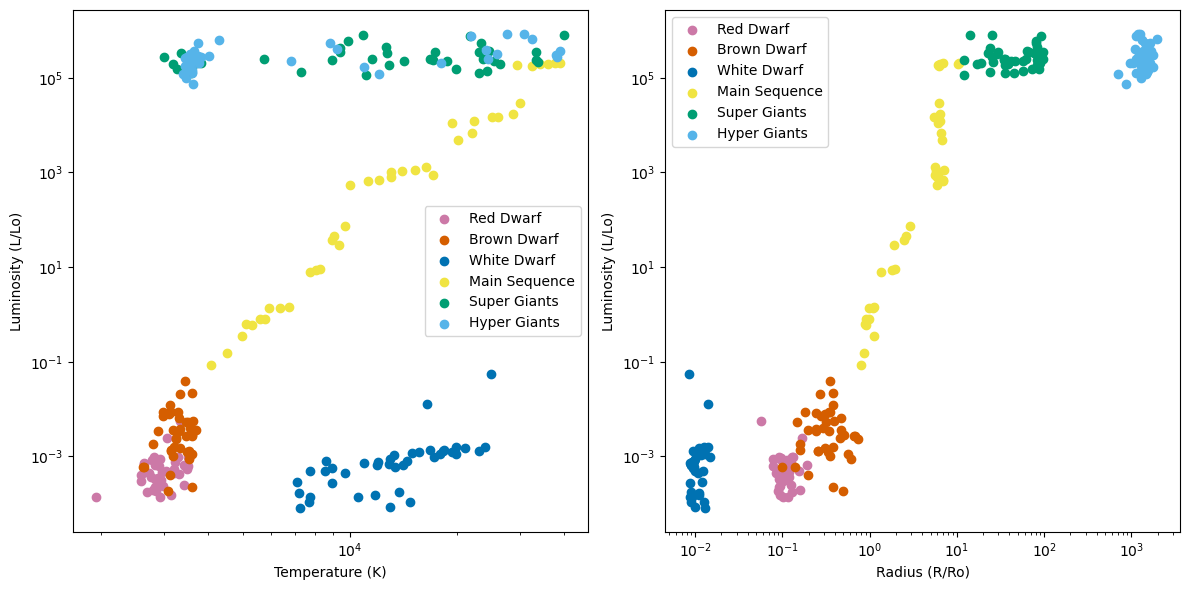

In [38]:
### ANSWER 

# labels = ["Red Dwarf", "Brown Dwarf", "White Dwarf", "Main Sequence", "Super Giants", "Hyper Giants"]

column_str = "Star type"
# scolor = stars_data["Star color"].unique()

labels = stars_data[column_str].unique()


# fig, ax = plt.subplots(1,1, figsize=(10, 7))
fig = plt.figure(figsize = (12,6))
plt.subplot(121)
for i in range(len(labels)):
    sdata = stars_data[stars_data[column_str] == labels[i]] # 2 points for each correct mask and label
    plt.scatter(sdata["Temperature (K)"], sdata["Luminosity(L/Lo)"], c=scolor[i],  label= labels[i])

# ax.set( yscale ='log', xscale ='log', ylabel ="Luminosity (L/Lo)", xlabel = "Temperature (K)")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Luminosity (L/Lo)")
plt.xlabel("Temperature (K)")

plt.subplot(122)
for i in range(len(labels)):
    sdata = stars_data[stars_data[column_str] == labels[i]] # 2 points for each correct mask and label
    plt.scatter(sdata["Radius(R/Ro)"], sdata["Luminosity(L/Lo)"], c=scolor[i],  label= labels[i])

# ax.set( yscale ='log', xscale ='log', ylabel ="Luminosity (L/Lo)", xlabel = "Temperature (K)")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Luminosity (L/Lo)")
plt.xlabel("Radius (R/Ro)")

fig.tight_layout()
# plt.savefig("HR_diagram.png")

# plt.gca().invert_xaxis()


In [45]:
sns.__version__

'0.12.2'

/home/luciano/anaconda3/envs/cmse491/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/luciano/anaconda3/envs/cmse491/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/luciano/anaconda3/envs/cmse491/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/luciano/anaconda3/envs/cmse491/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed i

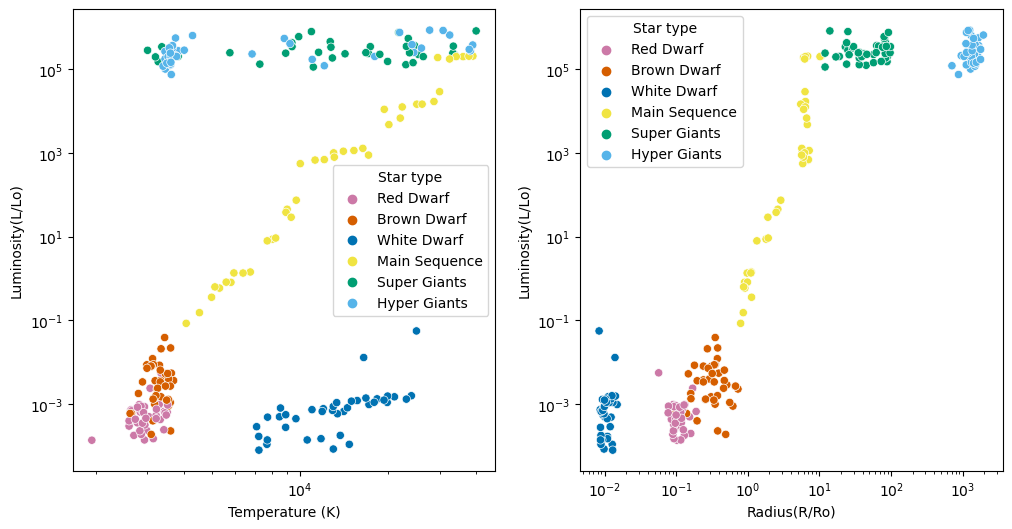

In [44]:
import seaborn as sns

fig, ax = plt.subplots(1,2,figsize = (12,6))
sns.scatterplot(data = stars_data, x = "Temperature (K)", y = "Luminosity(L/Lo)", hue = "Star type", palette = scolor, ax = ax[0])
sns.scatterplot(data = stars_data, x = "Radius(R/Ro)", y = "Luminosity(L/Lo)", hue = "Star type", palette = scolor, ax = ax[1])
for a in ax:
    a.set(xscale = 'log', yscale = 'log')

### ANSWER
The points are given in the text above. Partial credit if only one of the plot has the correct characteristics.

Learning goals: 
- I want students to learn to make good data visualization. This requires a lot of coding, but once they define the characteristics of one plot they can copy and paste for the next one.
- Practice using `for` loops and masks. Again if they do it for the first plot they can copy and paste for the second.


&#9989;&nbsp; **Answer the following (4 points):** Looking at the plots, 
1. What are the stars whose Luminosity is highly correlated with Temperature and Radius? (1 point)
2. Now that you've looked at the two plots, which of the two plots suggested that astronomers use the names: "Red Dwarf", "Brown Dwarf", "White Dwarf", "Main Sequence", "Super Giants", "Hyper Giants"? (1 point)
3. Looking at the main sequence stars. Which plot has the largest slope? Justify your answer and look carefully at the range of values the data span. (2 points)

<font size=8 color="#009600">&#9998;</font> Put your answer here

### ANSWER
1. (1 point) Main sequence. No partial credit.
2. (1 point) Radius vs Luminosity. No partial credit.
3. 0 points if blank, 
    0.5 points if they attempt it, but are way off or no justification, 
    1.0 point for answering but justification is confusing or contraddicting, 
    1.5 points if the answer is good, but is still missing that one thing. 
    2 points Good answer. Temp vs Lum. The main sequence stars span 2 orders of magnitude in Temperature, and barely one in radius.


---
<a id="part_3"></a>

## Part 3: Fitting curves to data. The Luminosity Function (14 points)

[Back to Top](#toc)


Now that we have visualized our data we can formulate our question. 

> What is the relation between Luminosity, Temperature, and Radius?

In the following we will try and find this relation.


### Part 3.1: Model
In the above plots we notice that the main sequence stars fall on a (almost) straight line in both plots. Since both axis are on a log-log plot we can infer that there exist a power-law relation between the Luminosity, $L$, Temperature, $T$ and radius, $R$. Specifically, 

$$ L  = A R^{\alpha} T^{\beta} $$

For the sake of simplicity, we will try to model only the relation between Luminosity and Temperature. In order to simplify the above equation we look at the description of our data. Notice that the Luminosity is a relative quantity, _i.e._ we have information of the ratio between the real luminosity divided (normalized) by the luminosity of the sun, $L_o = 3.828 \times 10^{26}$. Therefore, it would be better to compare the relative luminosity with the relative temperature. The relation now becomes

$$ \frac{L}{L_o} = \left( \frac{T}{T_o} \right )^{\beta} $$ 

where $T_o = 5780$ K is the temperature of the sun. 

&#9989;&nbsp; **Do this (6 points):** 
- Add a new column to your dataset and call it `Normalized Temperature`. This column is obtained by dividing the `Temperature (K)` column by the temperature of the sun $T_o = 5780$ K. (2 points)
- Write a function called `lum_model` that computes the relative luminosity according to the equation above (i.e. $\left( \frac{T}{T_o} \right )^{\beta}$). Remember, you now have a new column that is the normalized temperature, $\frac{T}{T_0}$, so this simplifies your function and you don't need to worry about doing the normalization inside the function if you give it the right temperature data. (4 points)

In [ ]:
# Put your code here

In [ ]:
### ANSWER ###
Tsun = 5780
stars_data["Normalized Temperature"] = stars_data["Temperature (K)"]/Tsun
# 1 point for correct math + 1 point for adding it to the dataframe.

def lum_model(T, beta):
    return  T**beta

# 0.5 point for correct name
# 1 point for correct order of the inputs. No partial credit
# 1 point for correct math. No partial credit
# 0.5 points for return statement

### Part 3.2: Fit the model

&#9989;&nbsp; **Do this (4 points):** 

- Now use `curve_fit` with the above function to find the parameter $\beta$ by fitting the `Luminosity(L/Lo)` and `Normalized Temperature` of the **main sequence stars only** (you'll want to use a mask to select these stars).

- What is the value of $\beta$?

In [ ]:
# Put your code here

In [ ]:
### ANSWER ###
mask = stars_data["Star type"] == "Main Sequence"
main_sequence = stars_data[mask]

popt, pcov = curve_fit(lum_model, 
                       main_sequence["Normalized Temperature"], 
                       main_sequence["Luminosity(L/Lo)"])

# 1 point for selecting only the main sequence stars. They can use a mask or whatever they want.
# 0.5 point for calling curve_fit
# 0.5 point for correct placement of lum model
# 0.5 point for correct placement of y values (temperature)
# 0.5 point for correct placement of x values (luminosity)
# 0.5 point for assigning outputs (popt, pcov)

print(popt)
# 0.5 point for printing beta


### Part 3.3 Check your model (5 points)

&#9989;&nbsp; **Do this (3 points):**  Make a plot comparing your model and the data. Don't forget to log-scale your axis, label them, and add a legend.

In [ ]:
# Put your code here

In [ ]:
### ANSWER
# 1 point for plotting the data. No partial credit
# 1 point for plotting the fitted curve. No partial credit
# 1 point for labeling the figure (x and y axis, log scaled, legend). Partial credit if only legend missing. 0 points if no x-y labels but legend is present. They should always have labels on their axis

x_col = "Normalized Temperature"
y_col = "Luminosity(L/Lo)"
fig, ax = plt.subplots(1,1, figsize=(10, 7))

ax.scatter(main_sequence["Normalized Temperature"], main_sequence["Luminosity(L/Lo)"], label = "Data")
ax.plot( main_sequence["Normalized Temperature"], 
          lum_model( main_sequence["Normalized Temperature"], *popt), label = "Fit")

ax.set( yscale ='log', xscale ='log', ylabel ="Relative Luminosity (L/Lo)", xlabel = "Normalized Temperature (T/To)")
ax.legend()
# ax.invert_xaxis()

&#9989;&nbsp; **Answer the following (4 points):** 
- Do you think your model is a good model? Clearly justify your answer (looking for more than a "yes" or "no" answer). (2 points)
- How might you improve your model? (2 points)

In [ ]:
# Put any additional code here

<font size=8 color="#009600">&#9998;</font> Put your answer here

In [ ]:
### ANSWER 
#Using R^2
def get_r_val(y,f_y):
    y_SS = np.sum(np.power((y-np.ones_like(y)*np.mean(y)),2.0))
    y_SR = np.sum(np.power(y-f_y,2.0))
    return 1 - y_SR/y_SS

r2 = get_r_val(main_sequence["Luminosity(L/Lo)"], lum_model( main_sequence["Normalized Temperature"], *popt) )
print(f"R2 = {r2:.2f}")

# Q1: 
# 0 points if blank, 
# 0.5 points if they attempt it, but are way off or no justification 
# 1.0 point for answering but justification is confusing or contraddicting, 
# 2 points Clearly stated answer with well-articulated justification.
# 2 pts example: good(bad) model because R^2 is close to (not close enough to) 1
#   note: a quantified justification is not necessary

# Q2: Be more lenient on this one. As long as they answer it with sound logic they get 2 points 
# 0 points if blank, 
# 0.5 points if they attempt it, but are way off. They talk about speed of light or black holes or whatever.
# 1.0 point for answering but justification is confusing or contraddicting, 
# 2 points Good answer. 

---
<a id="part_4"></a>

## Part 4: Solving ODEs (23 total points)

[Back to Top](#toc)

Modeling population growth is different for populations where individuals from the population are removed, or "harvested," at a constant rate. For example, if a village relies on fishing from the lake nearby to survive, we could model the population of the fish using harvesting. In this example, assume the village needs exactly **90** fish per month from the lake.

Model of population for fish goes like:

$$\frac{dP}{dt} = r P (K - P) - H$$

- $r$ is a natural growth factor: **0.002** (fish * month)$^{-1}$
- $K$ is the maximum supportable population of the lake: **700** fish
- $H$ is the harvesting rate: **90** fish/month
- $P$ is the value of the population (fish)
- $dP/dt$ is the rate of change of the population (fish per month)

It may also be useful in this section to remember how values can be calculated incrementally using derivatives. For example, if we know that the value of $x$ is $x_1$ at a given time, and we know value of the derivative at that time is $dx/dt$, then we can compute the value of $x$ at a short time ($\Delta t$) later:

$$x_2 = x_1 + \frac{dx}{dt}\Delta t$$

### 4.1 Write a function for the derivative (4 points)

&#9989;&nbsp; **Task**

Write a function to calculate and **return** the derivative $dP/dt$. Use the template below to get started on your function.

In [ ]:
def derivs(______): # inputs?
    
    # some constants provided...
    r = 0.002
    K = 700
    H = 90
    
    # more code?

In [ ]:
### ANSWER ###

def derivs(P):
    r = 0.002
    K = 700
    H = 90
    
    dPdt = r * P * (K - P) - H
    return dPdt

In [ ]:
### ANSWER ###
# 1 -- input P (or more, as long as function computes deriv correctly)
# 2 -- correct equation for dPdt
# 1 -- return statement for dPdt

### 4.2 Compute a derivative (1 point)

&#9989;&nbsp; **Task**

The population of the lake is estimated to be 85 fish. Call your `derivs` function to show the value of $dP/dt$ when population is 85.

In [ ]:
## your code here

In [ ]:
### ANSWER ###
derivs(85)

In [ ]:
### ANSWER ###
# 0.5 -- calling derivs function
# 0.5 -- derivs(85)

### 4.3 Compute population values (7 points)

The code below provides an array of `times` spanning 5 years at 1-month increments. It also provides a matching array for the `pops`, and the first population (85 fish) has been inserted into the first position of the array.

&#9989;&nbsp; **Task**

Write a loop that uses your `derivs` function to compute values of the population over the course of the next 5 years. Insert your population values into the `pops` array. *When you are done, there should be no more zeros left in the pops array*

In [ ]:
# times, incrementing month by month, for a total of 5 years
dt = 1/12
times = np.arange(0, 5, dt)

# pops, initially set to a bunch of 0s, and the first value has already been inserted
pops = np.zeros(len(times))
pops[0] = 85

In [ ]:
## your code here

In [ ]:
### ANSWER ###

for i in range(1, len(pops)):
    pop_old = pops[i-1]
    pop_new = pop_old + derivs(pop_old) * dt
    pops[i] = pop_new

In [ ]:
### ANSWER ###
# 1 -- set up a loop
# 1 -- loop goes through the correct number of iterations to populate pops
# 1 -- any calling of the derivs function inside the loop
# 1 -- any multiplication like (derivs(...) * dt)
# 2 -- correctly calculating the value for new population every iteration of the loop
# 1 -- inserting the new population value into pops

### 4.4 Plot population growth (3 points)

&#9989;&nbsp; **Task**

Create a plot that shows the population growth of fish in the lake over 5 years, assuming a starting population value of **85**. Make sure to include axis labels and a title for your plot.

In [ ]:
## your code here

In [ ]:
### ANSWER

plt.plot(times, pops)
plt.xlabel("years")
plt.ylabel("number of fish")
plt.title("Fish population growth")

In [ ]:
### ANSWER ###
# 1 -- plotting the times array
# 1 -- plotting the pops array
# 0.5 -- a correct curve
# 0.5 -- axis labels and a title

### 4.5 Plotting alternative models (6 points)

It turns out it is hard to count the number of fish in a lake. The original estimate wsa 85, but it could be off by plus or minus 15 fish. The real number could be anywhere between 70 and 100.

&#9989;&nbsp; **Task**

Compute and plot population growth assuming different starting values:
- At time = 0, $P_0$ = 85 (you've already done this one)
- At time = 0, $P_0$ = 70
- At time = 0, $P_0$ = 100

Your plot should show three different curves, which should be labeled in a legend as well, so you can easily see the different starting values of the population, and the corresponding curves. Make sure to include axis labels and a title.

In [ ]:
## your code here

In [ ]:
### ANSWER

dt = 1/12
times = np.arange(0, 5, dt)

pops70 = np.zeros(len(times))
pops85 = np.zeros(len(times))
pops100 = np.zeros(len(times))

pops70[0] = 70
pops85[0] = 85
pops100[0] = 100

for i in range(1, len(times)):
    pop_old70 = pops70[i-1]
    pop_new70 = pop_old70 + derivs(pop_old70) * dt
    pops70[i] = pop_new70
    
    pop_old85 = pops85[i-1]
    pop_new85 = pop_old85 + derivs(pop_old85) * dt
    pops85[i] = pop_new85
    
    pop_old100 = pops100[i-1]
    pop_new100 = pop_old100 + derivs(pop_old100) * dt
    pops100[i] = pop_new100

plt.plot(times, pops70, label = "P0 = 70")
plt.plot(times, pops85, label = "P0 = 85")
plt.plot(times, pops100, label = "P0 = 100")
plt.xlabel("years")
plt.ylabel("number of fish")
plt.title("Fish population growth")
plt.legend()

In [ ]:
### ANSWER ### 
# 1 -- creating three different pops arrays
# 1 -- setting the three different starting populations
# 2 -- calculating all the populations correctly
# 1 -- plotting pop versus times for all three setups
# 0.5 -- curves are all correct
# 0.5 -- axis labels and a title

### 4.6 Reflecting on the model results (2 points)

&#9989;&nbsp; **Task**

What stands out to you about the plot from 4.5? What do these results mean for the real life consequences of this village and its food supply?

<font size=8 color="#009600">&#9998;</font> Put your answer here

In [ ]:
### ANSWER ###
# 1 -- the curve for 70 goes down below 0
# 1 -- this means the village will run out of food if the lake only has 70 fish in it

---

### Congratulations, you're done!
[Back to Top](#toc)

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" section, find the submission folder link for Homework #3, and upload it there.

&#169; 2023 Copyright the Department of Computational Mathematics, Science and Engineering.